In [1]:
pip install polars matplotlib typing_extensions==4.11.0 great_tables numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 12.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.7/109.7 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.7/39.7 MB 74.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 104.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 95.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 103.5 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 107.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 51.2 MB/s eta 0:00:00


In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from great_tables import GT, style, loc
from collections import defaultdict
from dataclasses import dataclass
from enum import Enum

# Utilities

In [3]:
schema = pl.Schema({"Timers":pl.UInt64(), "TxTime":pl.UInt64(), "RxTime":pl.UInt64()})

class Library(Enum):
    libfabric = "libfabric"
    native = "native"

class Format(Enum):
    _720= "720"
    _1080= "1080"
    _2160= "2160"

class Completion(Enum):
    spin = "Spin"
    wait = "Wait"
    none = ""
    
class Transport(Enum):
    tcp = "Tcp"
    verbs = "Verbs"
    shm = "SHM"
    none = ""

class TransferMode(Enum):
    oneway = "OneWay"
    reflect = "Reflect"
    none = ""

class Movement(Enum):
    d2d = "Cuda2Cuda"
    dh2hd = "Cuda2Host2Host2Cuda"
    h2d = "Host2Cuda"
    d2h = "Cuda2Host"

    def to_study_name(self) -> str:
        match self:
            case Movement.d2d:
                return "Device-to-Device"
            case Movement.dh2hd:
                return "Device-to-Host-to-Host-to-Device"
            case Movement.h2d:
                return "Host-to-Device"
            case Movement.d2h:
                return "Device-to-Host"
    
class Test(Enum):
    mxl_fabrics="MXLFabrics"
    native_cuda="NativeCuda"

@dataclass(frozen=True, eq=True)
class TestConfiguration:
    library: Library
    format: Format
    completion: Completion
    test: Test
    movement: Movement
    transport: Transport
    tx_mode: TransferMode

def get_mxlfabrics_test_name(conf: TestConfiguration):
    return f"{conf.test.value}+{conf.movement.value}+{conf.transport.value}+{conf.tx_mode.value}+{conf.completion.value}"

def get_nativecuda_test_name(conf: TestConfiguration):
    return f"{conf.test.value}+{conf.movement.value}"

def diff_loader(data):
    return data["RxTime"] - data["TxTime"]

def timers_loader(data):
    return data["Timers"]

def load_data(directory, loader,libraries=Library, formats=Format, completions=Completion, tests=Test, movements=Movement,  transports=Transport, tx_modes=TransferMode):
    data = {}
    perf = {}
    for format in formats:
        for tx_mode in tx_modes:
            for test in tests:
                if test == Test.mxl_fabrics:
                    for comp in completions:
                        for transport in transports:
                            for library in libraries:
                                for movement in movements:
                                    test_conf = TestConfiguration(library, format, comp, test, movement, transport, tx_mode)
                                    file_name = f"{directory}/{format.value}/{library.value}/{get_mxlfabrics_test_name(test_conf)}"
                                    data[test_conf] = loader(pl.read_csv(f"{file_name}.csv", schema=schema))
                                    perf[test_conf] = pl.read_csv(f"{file_name}.perf.csv")
                elif test == Test.native_cuda:
                    library = Library.native
                    test_conf = TestConfiguration(library, format, Completion.none, test, movement, Transport.none, TransferMode.none)
                    file_name = f"{directory}/{format.value}/{library.value}/{get_nativecuda_test_name(test_conf)}"
                    data[test_conf] = timers_loader(pl.read_csv(f"{file_name}.csv", schema=schema))
                    perf[test_conf] = pl.read_csv(f"{file_name}.perf.csv")
                        
    return data, perf

def make_table(data, perf_data, columns):
    table_data = defaultdict(list)    
    for (test_conf, values) in data.items():
        perf = perf_data[test_conf]
        for col in columns:
            table_data[col].append(getattr(test_conf, col))
        
        table_data["mean"].append(round(values.mean()/1e6,4))
        table_data["max"].append(round(values.max()/1e6,4))
        table_data["std"].append(round(values.std()/1e6,4))
        table_data["usage"].append(round((perf["task_clock_user"][0]+perf["task_clock_kernel"][0])/perf["time_elapsed"][0], 4))
        
                                   
    return GT(pl.DataFrame(table_data))


# Setup

In [4]:
# plot setup
plt.rcParams['figure.figsize'] = [14,8]
data_dir = "../data/mts-study"

# Transfers

## Device to Device Inter-Host

In [5]:
config = {"tests": [Test.mxl_fabrics], "movements": [Movement.d2d], "transports":[Transport.verbs], "tx_modes": [TransferMode.reflect], "completions": [Completion.wait, Completion.spin]}
data_d2d_interhost, perf_d2d_interhost = load_data(f"{data_dir}/d2d-interhost", timers_loader, **config)

### Comparison libfabric vs native for Device to Device Inter-Host transfers

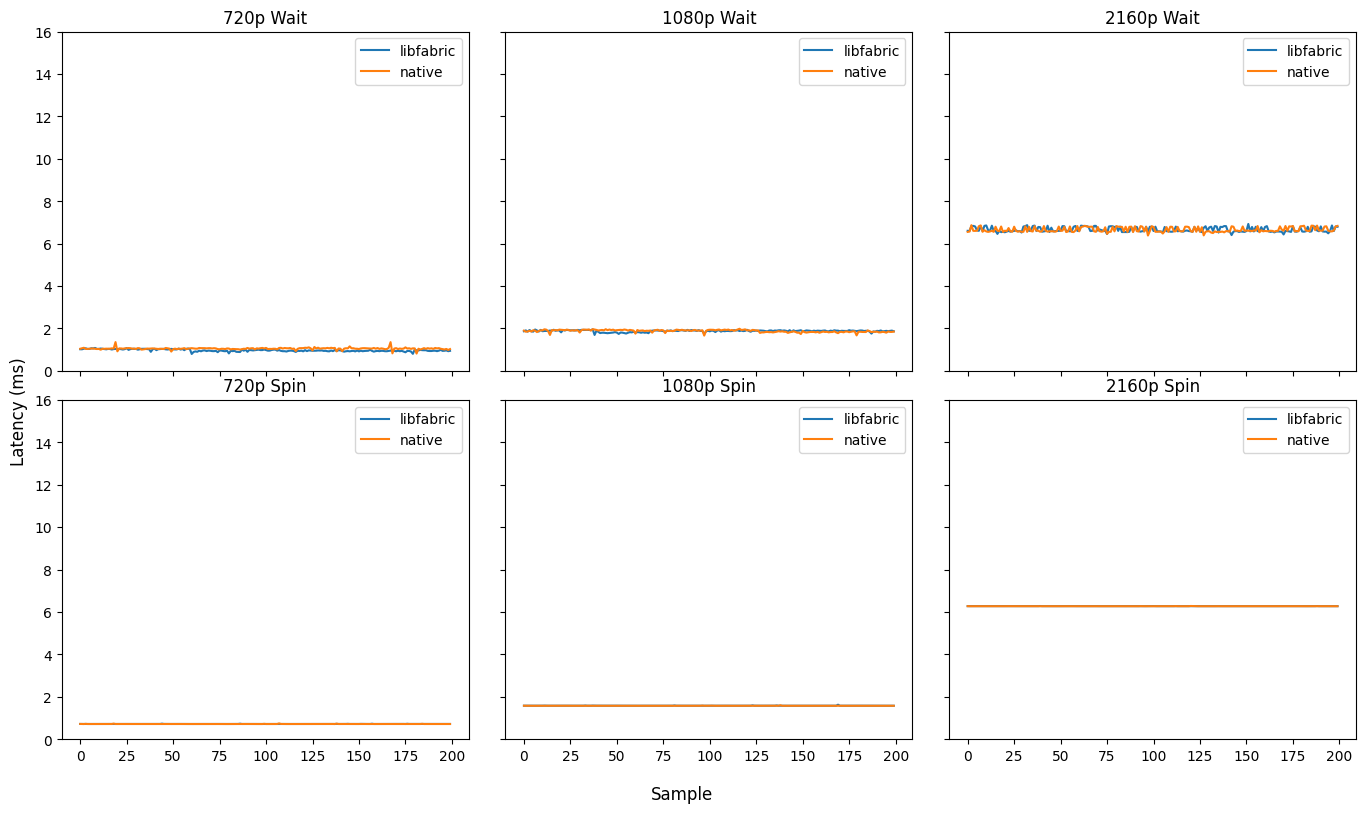

In [6]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for library in Library:
            axs[j][i].plot(data_d2d_interhost[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.d2d, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{library.value}")
            axs[j][i].legend()

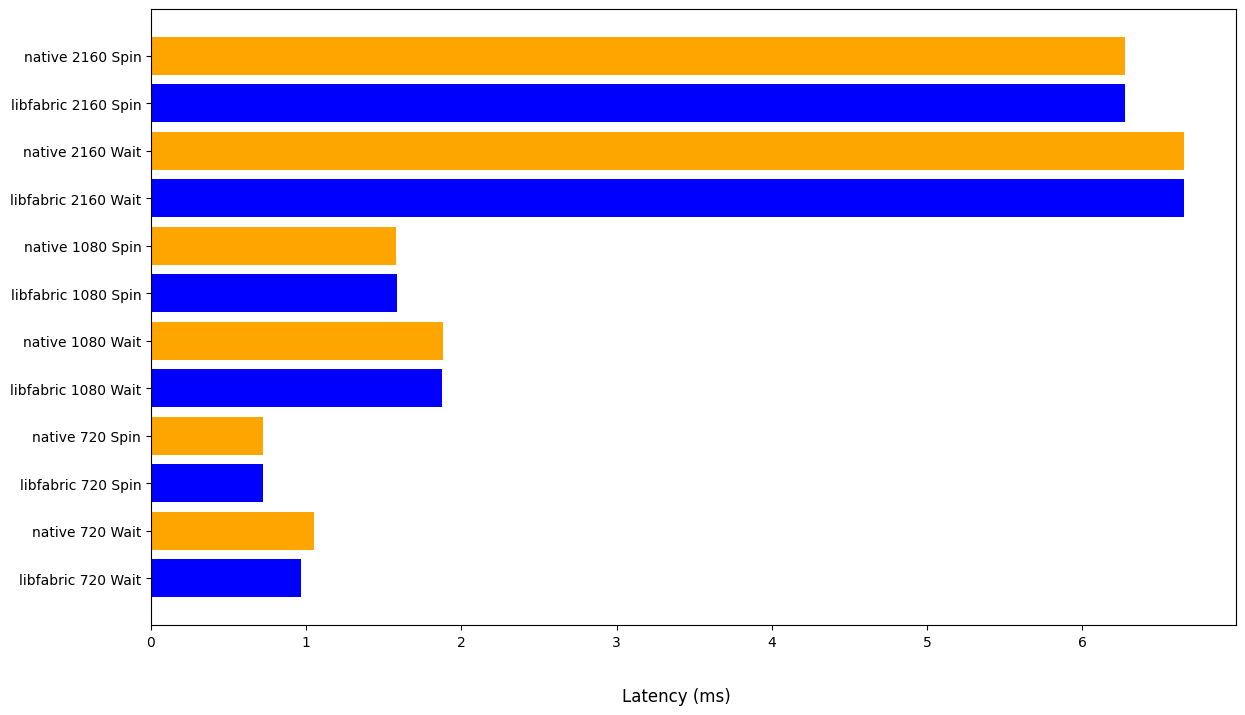

In [7]:
fig = plt.figure()
fig.supxlabel("Latency (ms)")

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        for library in Library:
            x = (f"{library.name} {format.value} {comp.value}")
            y=data_d2d_interhost[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.d2d, Transport.verbs, TransferMode.reflect)].mean()/1e6
            plt.barh(x,y, color="blue" if library==Library.libfabric else "orange")

In [8]:
data_columns=["format", "completion", "library"]
d2d_interhost_table = make_table(data_d2d_interhost, perf_d2d_interhost, columns=data_columns)

d2d_interhost_table
(
    d2d_interhost_table
    .tab_header(
        title="Device-to-Device transfer latency comparison",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["mean", "max", "std"]
    )
)

GT(_tbl_data=shape: (12, 7)
┌────────┬────────────┬───────────┬────────┬────────┬────────┬────────┐
│ format ┆ completion ┆ library   ┆ mean   ┆ max    ┆ std    ┆ usage  │
│ ---    ┆ ---        ┆ ---       ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│ enum   ┆ enum       ┆ enum      ┆ f64    ┆ f64    ┆ f64    ┆ f64    │
╞════════╪════════════╪═══════════╪════════╪════════╪════════╪════════╡
│ 720    ┆ Wait       ┆ libfabric ┆ 0.9692 ┆ 1.0824 ┆ 0.0497 ┆ 0.0136 │
│ 720    ┆ Wait       ┆ native    ┆ 1.0506 ┆ 1.3578 ┆ 0.0492 ┆ 0.0132 │
│ 720    ┆ Spin       ┆ libfabric ┆ 0.722  ┆ 0.7371 ┆ 0.0021 ┆ 0.0504 │
│ 720    ┆ Spin       ┆ native    ┆ 0.7205 ┆ 0.749  ┆ 0.003  ┆ 0.0473 │
│ 1080   ┆ Wait       ┆ libfabric ┆ 1.8779 ┆ 1.9574 ┆ 0.0431 ┆ 0.0088 │
│ …      ┆ …          ┆ …         ┆ …      ┆ …      ┆ …      ┆ …      │
│ 1080   ┆ Spin       ┆ native    ┆ 1.5806 ┆ 1.6037 ┆ 0.0019 ┆ 0.1006 │
│ 2160   ┆ Wait       ┆ libfabric ┆ 6.6566 ┆ 6.9277 ┆ 0.1163 ┆ 0.0073 │
│ 2160   ┆ Wait       ┆ native    ┆ 6.6545 ┆ 6.8695 ┆ 0.1141 ┆ 0.0084 │
│ 2160   ┆ Spin       ┆ libfabric ┆ 6.276  ┆ 6.2822 ┆ 0.001  ┆ 0.378  │
│ 2160   ┆ Spin       ┆ native    ┆ 6.2734 ┆ 6.2841 ┆ 0.0012 ┆ 0.3779 │
└────────┴────────────┴───────────┴────────┴────────┴────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x72b475bdb5d0>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x72b474116050>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'completion', 'library'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['mean', 'max', 'std'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x72b47609cfd0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(s

## Device to Host 2 Host to Device Inter-host

In [9]:
config = {"tests": [Test.mxl_fabrics], "movements": [Movement.d2d, Movement.dh2hd], "transports":[Transport.verbs], "tx_modes": [TransferMode.reflect], "completions": [Completion.wait, Completion.spin]}

# load data
data_dh2hd_interhost, perf_dh2hd_interhost = load_data(f"{data_dir}/dh2hd-interhost", timers_loader, **config)

### Comparison libfabric vs native for Device-to-Host-to-Host-to-Device transfers

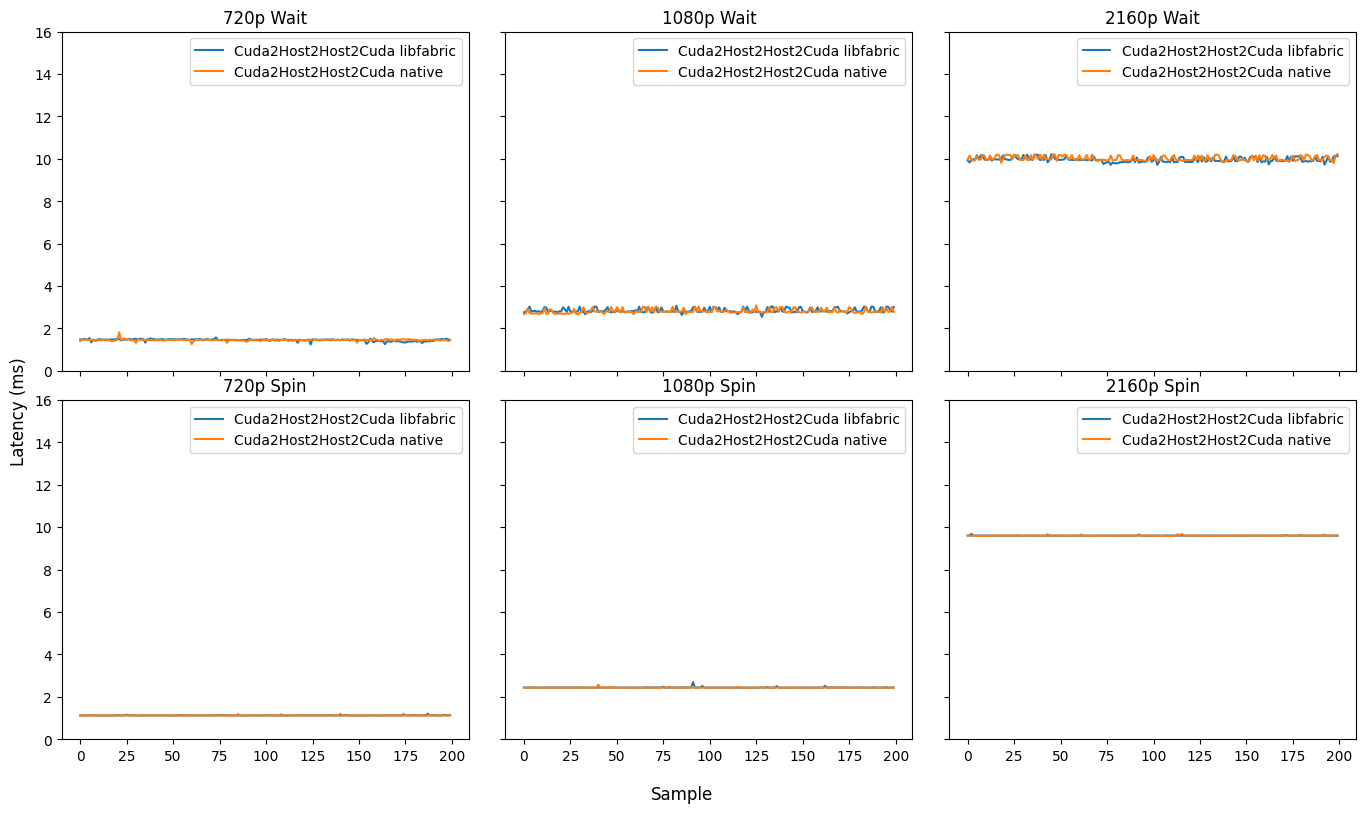

In [10]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for library in Library:
            axs[j][i].plot(data_dh2hd_interhost[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.dh2hd, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{Movement.dh2hd.value} {library.value}")
            axs[j][i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using libfabric

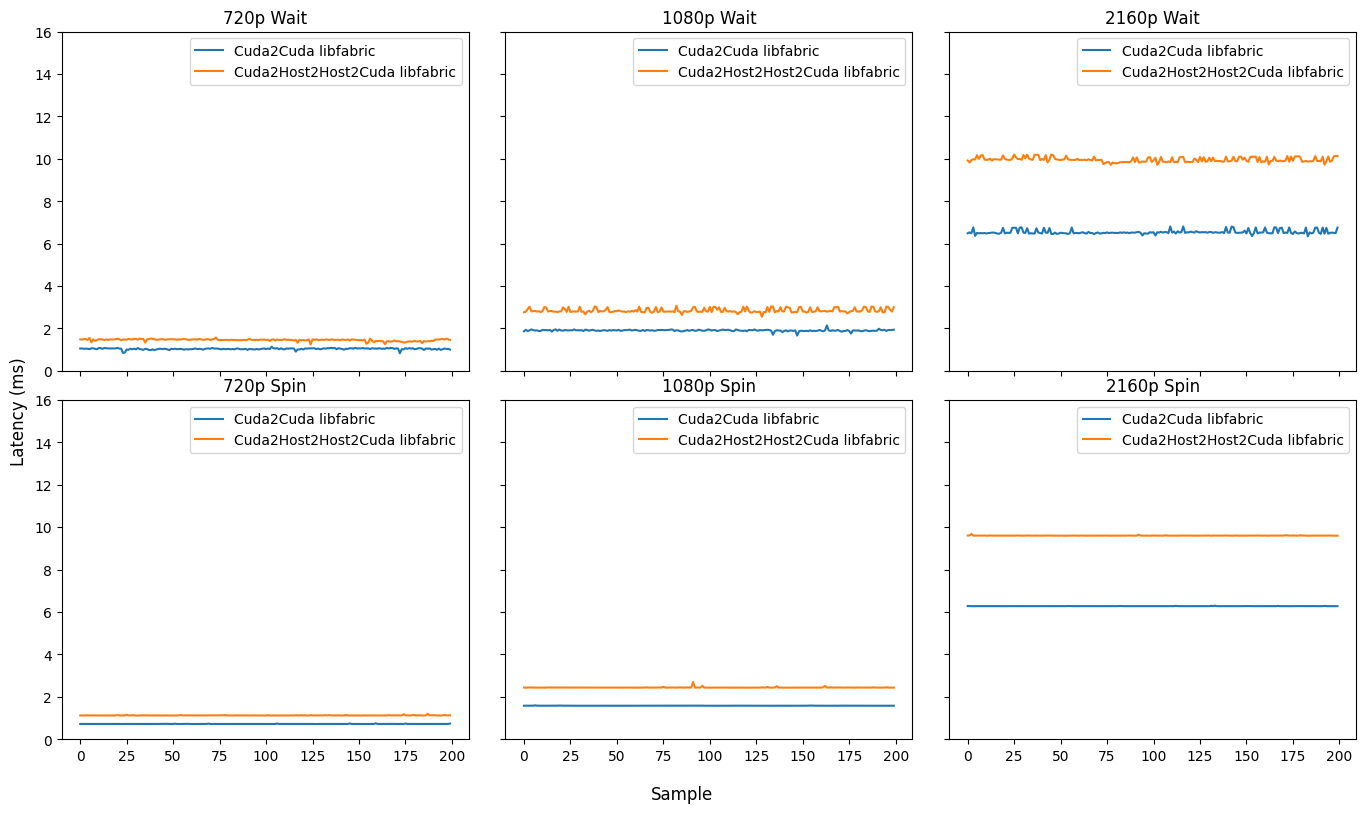

In [11]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

library = Library.libfabric

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for movement in config["movements"]:
            axs[j][i].plot(data_dh2hd_interhost[TestConfiguration(library, format, comp, Test.mxl_fabrics, movement, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{movement.value} {library.value}")
            axs[j][i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using native

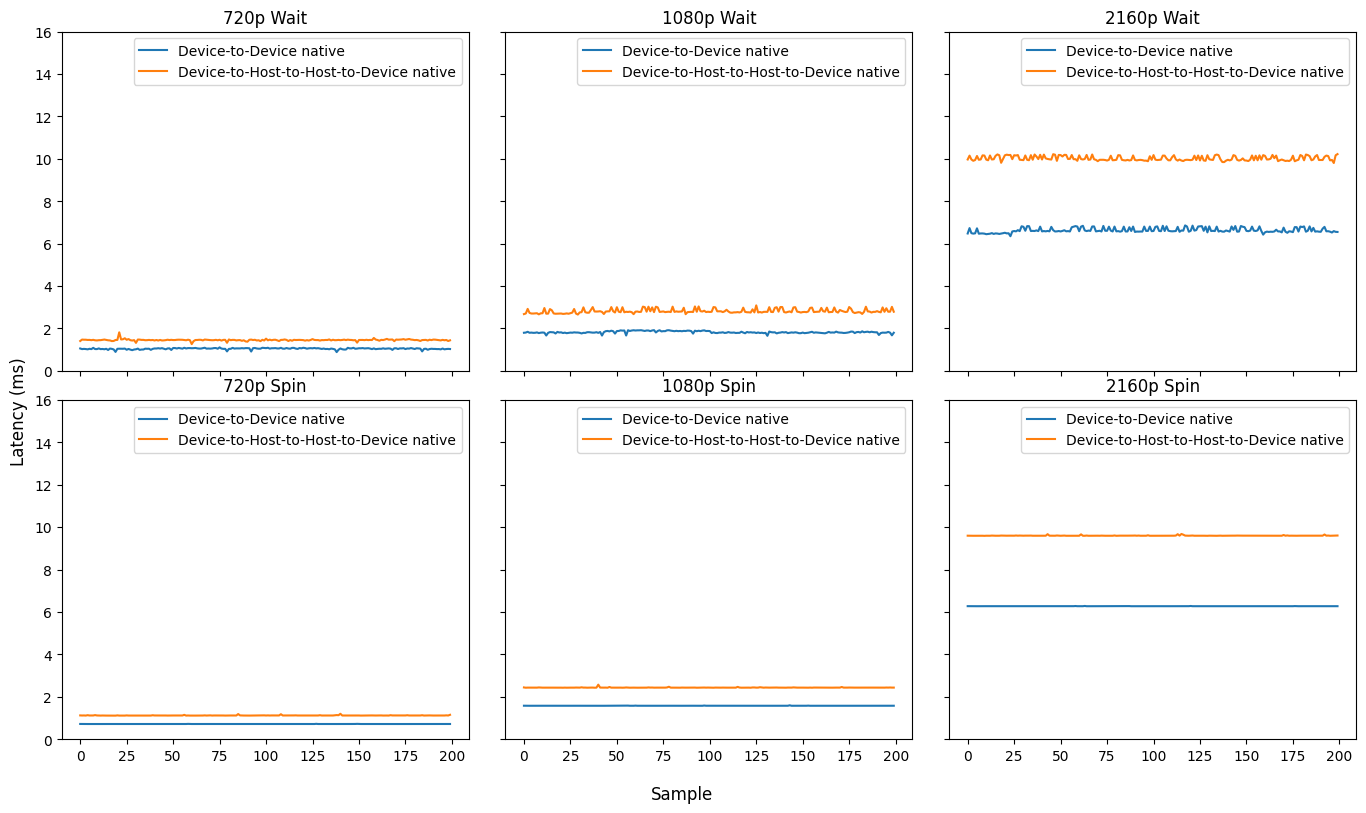

In [12]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

library = Library.native

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for movement in config["movements"]:
            axs[j][i].plot(data_dh2hd_interhost[TestConfiguration(library, format, comp, Test.mxl_fabrics, movement, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{movement.to_study_name()} {library.value}")
            axs[j][i].legend()

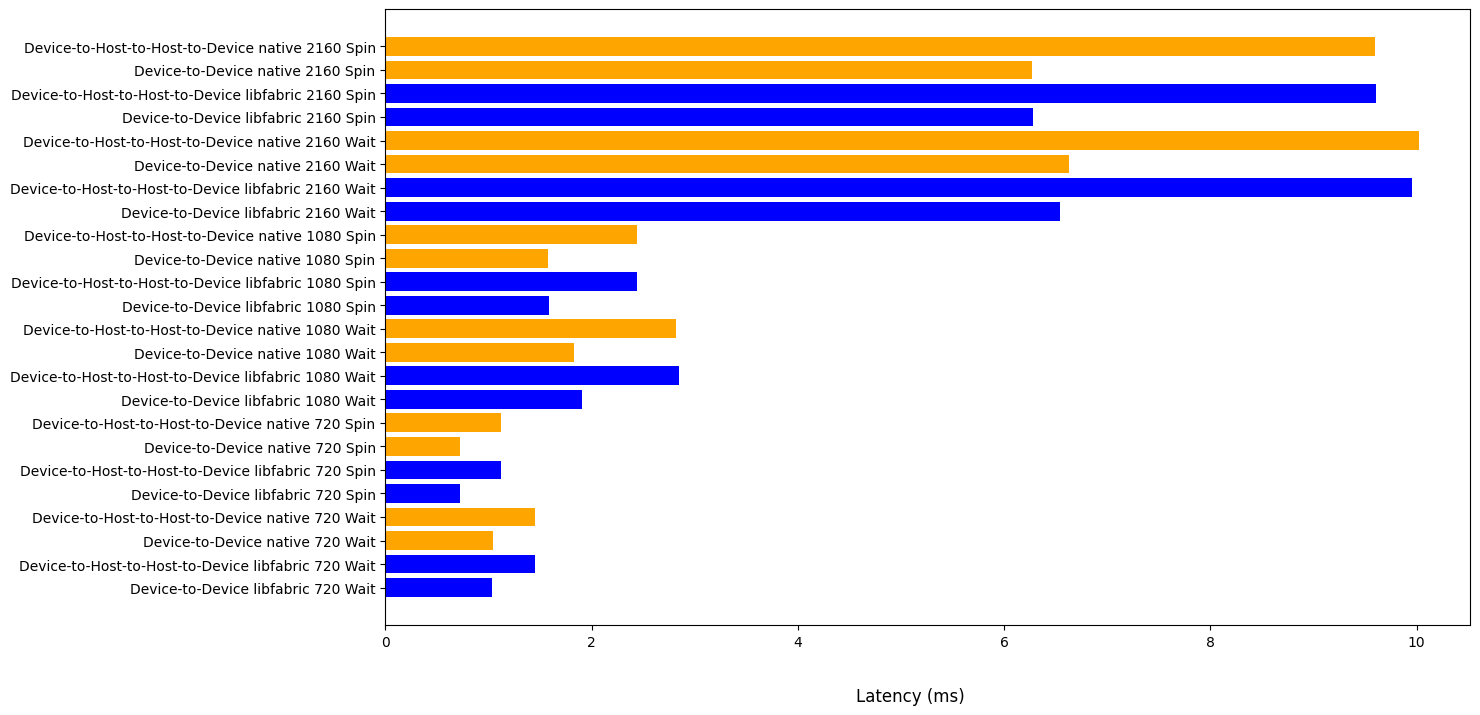

In [13]:
fig = plt.figure()
fig.supxlabel("Latency (ms)")

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        for library in Library:
            for movement in config["movements"]:
                x = (f"{movement.to_study_name()} {library.name} {format.value} {comp.value}")
                y=data_dh2hd_interhost[TestConfiguration(library, format, comp, Test.mxl_fabrics, movement, Transport.verbs, TransferMode.reflect)].mean()/1e6
                plt.barh(x,y, color="blue" if library==Library.libfabric else "orange")

In [14]:
data_columns = ["format", "completion", "library", "movement"]
dh2hd_interhost_table = make_table(data_dh2hd_interhost, perf_dh2hd_interhost, columns=data_columns)

dh2hd_interhost_table
(
    dh2hd_interhost_table
    .tab_header(
        title="Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["mean", "max", "std"]
    )
)


GT(_tbl_data=shape: (24, 8)
┌────────┬────────────┬───────────┬─────────────────────┬─────────┬─────────┬────────┬────────┐
│ format ┆ completion ┆ library   ┆ movement            ┆ mean    ┆ max     ┆ std    ┆ usage  │
│ ---    ┆ ---        ┆ ---       ┆ ---                 ┆ ---     ┆ ---     ┆ ---    ┆ ---    │
│ enum   ┆ enum       ┆ enum      ┆ enum                ┆ f64     ┆ f64     ┆ f64    ┆ f64    │
╞════════╪════════════╪═══════════╪═════════════════════╪═════════╪═════════╪════════╪════════╡
│ 720    ┆ Wait       ┆ libfabric ┆ Cuda2Cuda           ┆ 1.0376  ┆ 1.1401  ┆ 0.0352 ┆ 0.0136 │
│ 720    ┆ Wait       ┆ libfabric ┆ Cuda2Host2Host2Cuda ┆ 1.4551  ┆ 1.5746  ┆ 0.0493 ┆ 0.0261 │
│ 720    ┆ Wait       ┆ native    ┆ Cuda2Cuda           ┆ 1.0459  ┆ 1.109   ┆ 0.0328 ┆ 0.0097 │
│ 720    ┆ Wait       ┆ native    ┆ Cuda2Host2Host2Cuda ┆ 1.4546  ┆ 1.8179  ┆ 0.0401 ┆ 0.0224 │
│ 720    ┆ Spin       ┆ libfabric ┆ Cuda2Cuda           ┆ 0.7231  ┆ 0.7532  ┆ 0.0042 ┆ 0.0518 │
│ …      ┆ …          ┆ …         ┆ …                   ┆ …       ┆ …       ┆ …      ┆ …      │
│ 2160   ┆ Wait       ┆ native    ┆ Cuda2Host2Host2Cuda ┆ 10.0199 ┆ 10.2193 ┆ 0.1103 ┆ 0.1066 │
│ 2160   ┆ Spin       ┆ libfabric ┆ Cuda2Cuda           ┆ 6.2765  ┆ 6.2991  ┆ 0.0028 ┆ 0.3779 │
│ 2160   ┆ Spin       ┆ libfabric ┆ Cuda2Host2Host2Cuda ┆ 9.6025  ┆ 9.6817  ┆ 0.0075 ┆ 0.5798 │
│ 2160   ┆ Spin       ┆ native    ┆ Cuda2Cuda           ┆ 6.2742  ┆ 6.2852  ┆ 0.0015 ┆ 0.382  │
│ 2160   ┆ Spin       ┆ native    ┆ Cuda2Host2Host2Cuda ┆ 9.5999  ┆ 9.6786  ┆ 0.012  ┆ 0.5765 │
└────────┴────────────┴───────────┴─────────────────────┴─────────┴─────────┴────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x72b4760eb550>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.default: 1>, column_label='movement', column_align='center', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x72b4760a0c90>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'completion', 'library', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['mean', 'max', 'std'], built=None)]), _heading=Heading(title='Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x72b4760cffd0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, categ

## Host to Device Intra-Host

In [15]:
config = {"libraries": [Library.libfabric], "movements": [Movement.h2d], "transports":[Transport.shm], "tx_modes": [TransferMode.oneway], "completions":[Completion.wait,Completion.spin], "tests": [Test.mxl_fabrics, Test.native_cuda]}
data_h2d_intrahost, perf_h2d_intrahost = load_data(f"{data_dir}/h2d-intrahost", diff_loader, **config)

### Comparison libfabric vs native cuda for Host-to-Device transfers

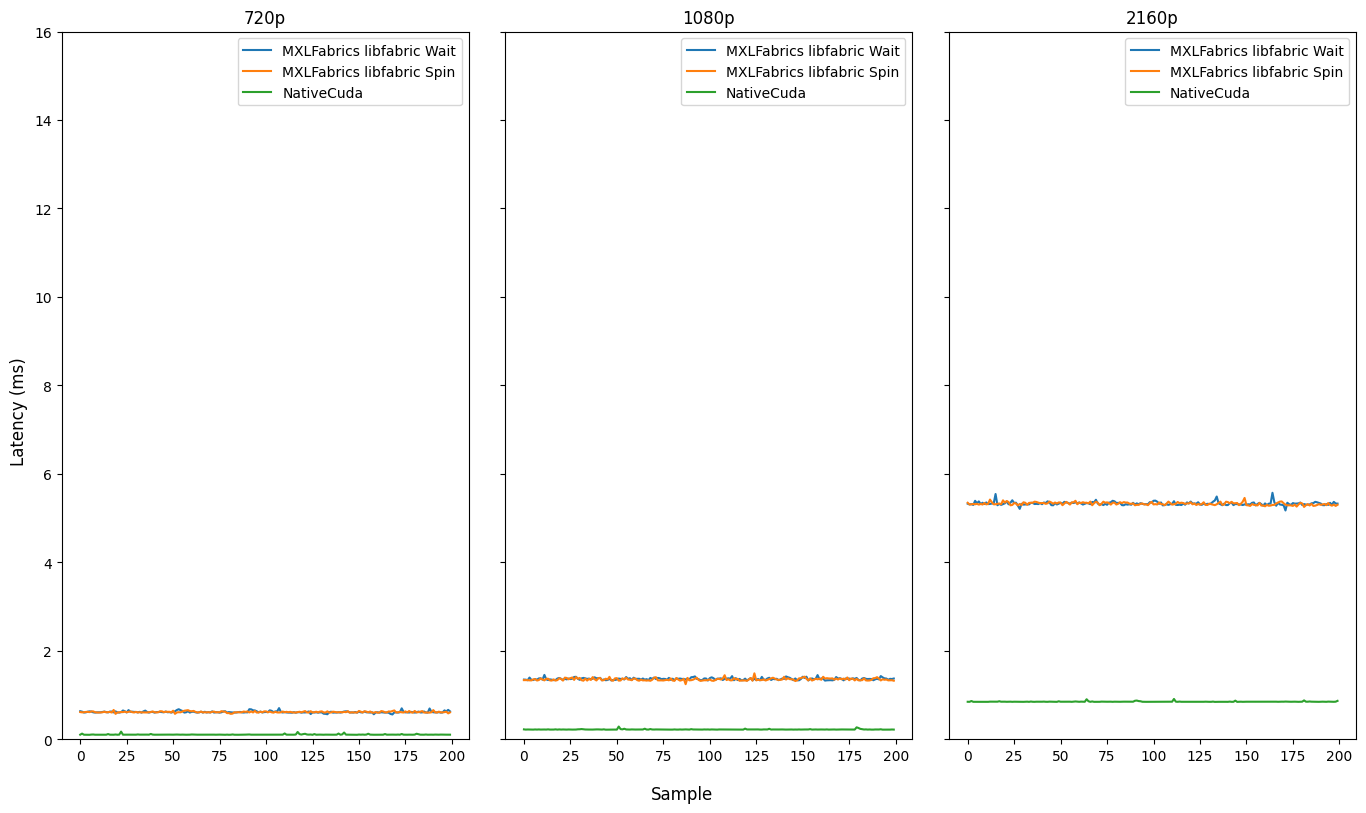

In [16]:
fig, axs = plt.subplots(nrows=1, ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for comp in config["completions"]:
        for library in config["libraries"]:
            axs[i].plot(data_h2d_intrahost[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.h2d, Transport.shm, TransferMode.oneway)]/1e6, label=f"{Test.mxl_fabrics.value} {library.value} {comp.value}")
    axs[i].plot(data_h2d_intrahost[TestConfiguration(Library.native, format, Completion.none, Test.native_cuda, Movement.h2d, Transport.none, TransferMode.none)]/1e6, label=f"{Test.native_cuda.value}")
    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(0, 16)
    axs[i].legend()

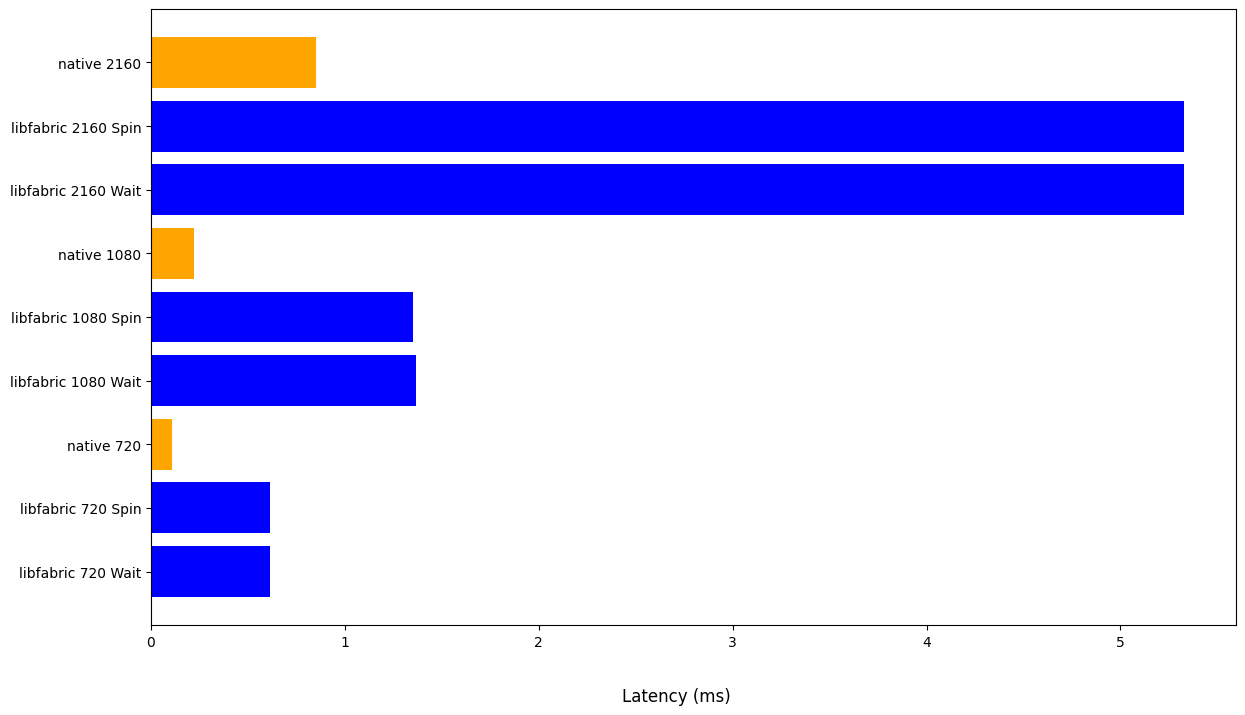

In [17]:
fig = plt.figure()
fig.supxlabel("Latency (ms)")

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        for library in config["libraries"]:
            x = (f"{library.name} {format.value} {comp.value}")
            y=data_h2d_intrahost[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.h2d, Transport.shm, TransferMode.oneway)].mean()/1e6
            plt.barh(x,y, color="blue")
    x = (f"native {format.value}")
    y=data_h2d_intrahost[TestConfiguration(Library.native, format,Completion.none, Test.native_cuda, Movement.h2d, Transport.none, TransferMode.none)].mean()/1e6
    plt.barh(x,y, color="orange")

In [18]:
data_columns = ["library","format", "completion", "test"]
h2d_intrahost_table = make_table(data_h2d_intrahost, perf_h2d_intrahost, columns=data_columns)

h2d_intrahost_table
(
    h2d_intrahost_table
    .tab_header(
        title="Host-to-Device transfer latency comparison",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["mean", "max", "std"]
    )
)

GT(_tbl_data=shape: (9, 8)
┌───────────┬────────┬────────────┬────────────┬────────┬────────┬────────┬────────┐
│ library   ┆ format ┆ completion ┆ test       ┆ mean   ┆ max    ┆ std    ┆ usage  │
│ ---       ┆ ---    ┆ ---        ┆ ---        ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│ enum      ┆ enum   ┆ enum       ┆ enum       ┆ f64    ┆ f64    ┆ f64    ┆ f64    │
╞═══════════╪════════╪════════════╪════════════╪════════╪════════╪════════╪════════╡
│ libfabric ┆ 720    ┆ Wait       ┆ MXLFabrics ┆ 0.6163 ┆ 0.7044 ┆ 0.0203 ┆ 0.0464 │
│ libfabric ┆ 720    ┆ Spin       ┆ MXLFabrics ┆ 0.6158 ┆ 0.6628 ┆ 0.0141 ┆ 0.0456 │
│ native    ┆ 720    ┆            ┆ NativeCuda ┆ 0.1064 ┆ 0.1734 ┆ 0.0087 ┆ 0.0146 │
│ libfabric ┆ 1080   ┆ Wait       ┆ MXLFabrics ┆ 1.3651 ┆ 1.4552 ┆ 0.0237 ┆ 0.0846 │
│ libfabric ┆ 1080   ┆ Spin       ┆ MXLFabrics ┆ 1.3537 ┆ 1.491  ┆ 0.0275 ┆ 0.0871 │
│ native    ┆ 1080   ┆            ┆ NativeCuda ┆ 0.2221 ┆ 0.2876 ┆ 0.0072 ┆ 0.022  │
│ libfabric ┆ 2160   ┆ Wait       ┆ MXLFabrics ┆ 5.3293 ┆ 5.5725 ┆ 0.0394 ┆ 0.3226 │
│ libfabric ┆ 2160   ┆ Spin       ┆ MXLFabrics ┆ 5.3255 ┆ 5.4559 ┆ 0.0305 ┆ 0.3242 │
│ native    ┆ 2160   ┆            ┆ NativeCuda ┆ 0.8502 ┆ 0.9113 ┆ 0.0075 ┆ 0.0569 │
└───────────┴────────┴────────────┴────────────┴────────┴────────┴────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x72b476a6ba50>, _boxhead=Boxhead([ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='test', type=<ColInfoTypeEnum.default: 1>, column_label='test', column_align='center', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x72b475513b90>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['library', 'format', 'completion', 'test'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['mean', 'max', 'std'], built=None)]), _heading=Heading(title='Host-to-Device transfer latency comparison', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x72b457724b50>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', '

## Device to Host Intra-Host

In [19]:
config = {"libraries": [Library.libfabric], "movements": [Movement.d2h], "transports":[Transport.shm], "tx_modes": [TransferMode.oneway], "completions":[Completion.wait,Completion.spin], "tests": [Test.mxl_fabrics, Test.native_cuda]}
data_d2h_intrahost, perf_d2h_intrahost = load_data(f"{data_dir}/d2h-intrahost", diff_loader, **config)

### Comparison libfabric vs native cuda for Device-to-Host transfers

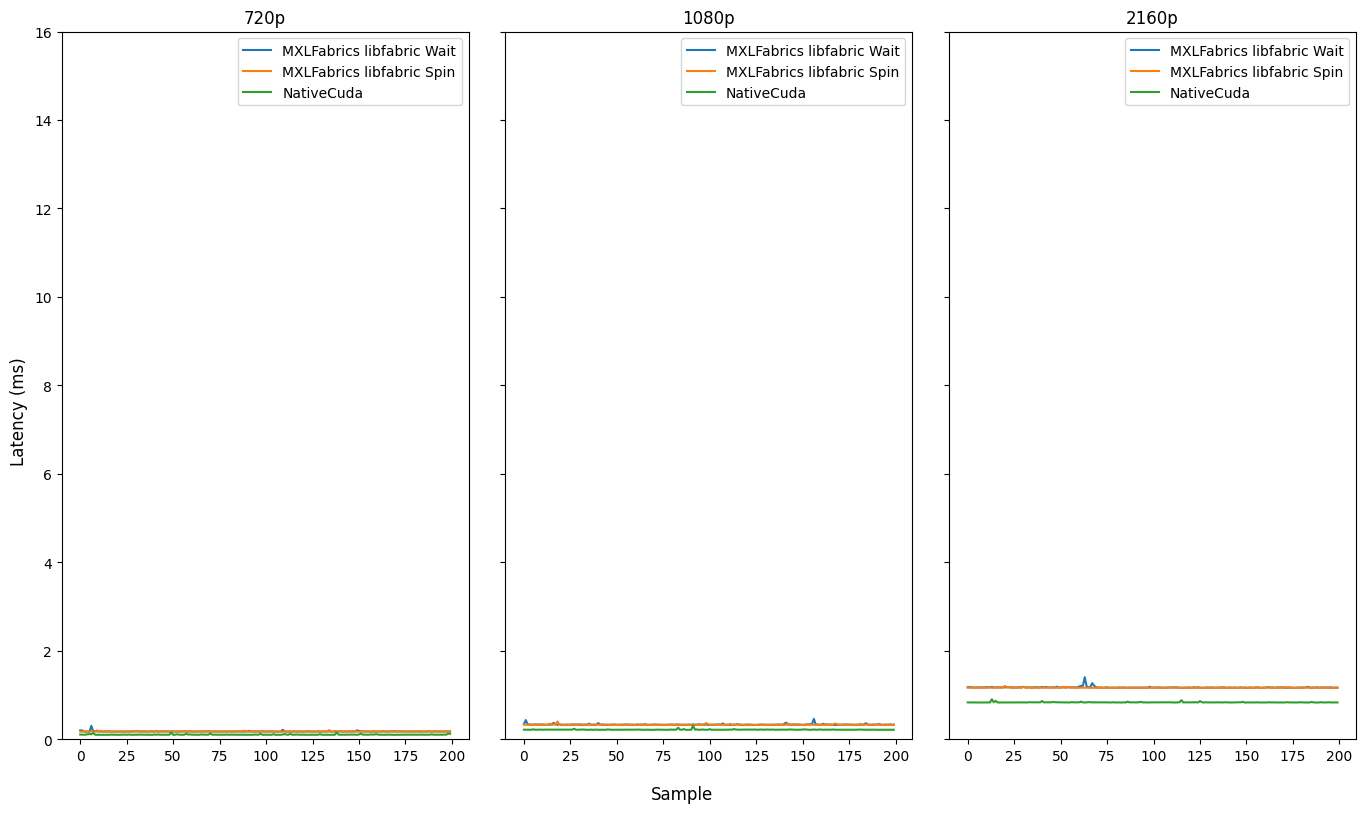

In [20]:
fig, axs = plt.subplots(nrows=1, ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for comp in config["completions"]:
        for library in config["libraries"]:
            axs[i].plot(data_d2h_intrahost[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.d2h, Transport.shm, TransferMode.oneway)]/1e6, label=f"{Test.mxl_fabrics.value} {library.value} {comp.value}")
    axs[i].plot(data_d2h_intrahost[TestConfiguration(Library.native, format, Completion.none, Test.native_cuda, Movement.d2h, Transport.none, TransferMode.none)]/1e6, label=f"{Test.native_cuda.value}")
    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(0, 16)
    axs[i].legend()

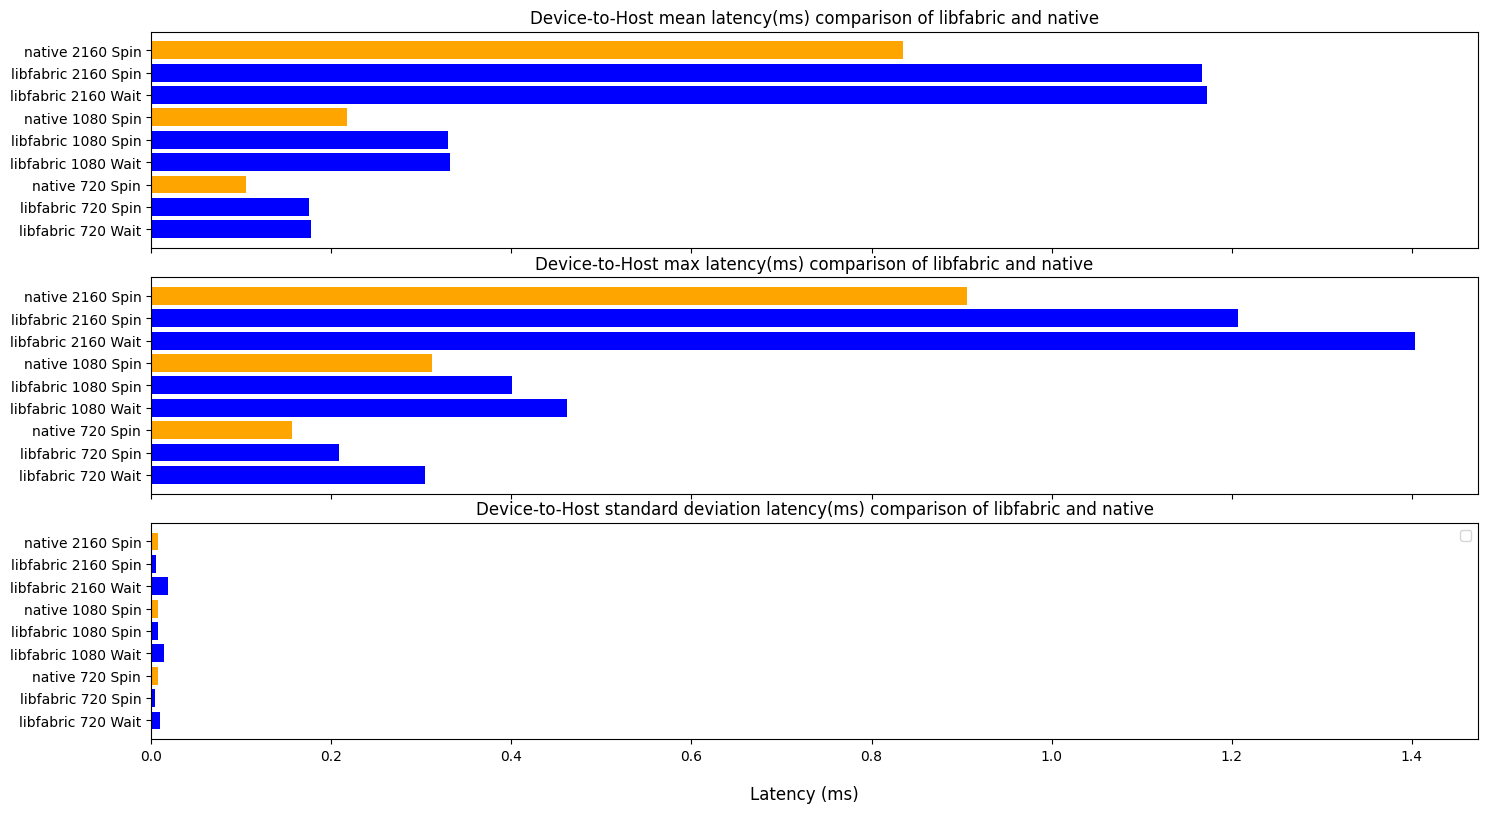

In [21]:
fig, axs = plt.subplots(nrows=3, ncols=1,sharex=True)
fig.supxlabel("Latency (ms)")
fig.tight_layout()

axs[0].set_title("Device-to-Host mean latency(ms) comparison of libfabric and native")
axs[1].set_title("Device-to-Host max latency(ms) comparison of libfabric and native")
axs[2].set_title("Device-to-Host standard deviation latency(ms) comparison of libfabric and native")

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        for library in config["libraries"]:
            x = [(f"{library.name} {format.value} {comp.value}")]
            y=data_d2h_intrahost[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.d2h, Transport.shm, TransferMode.oneway)]/1e6
            ymean=y.mean()
            ymax=y.max()
            ystd=y.std()
            axs[0].barh(x,ymean, color="blue")
            axs[1].barh(x,ymax, color="blue")
            axs[2].barh(x,ystd, color="blue")
            plt.legend("")
    x = (f"native {format.value} {comp.value}")
    y = data_d2h_intrahost[TestConfiguration(Library.native, format,Completion.none, Test.native_cuda, Movement.d2h, Transport.none, TransferMode.none)]/1e6
    ymean=y.mean()
    ymax=y.max()
    ystd=y.std()
    axs[0].barh(x,ymean, color="orange")
    axs[1].barh(x,ymax, color="orange")
    axs[2].barh(x,ystd, color="orange")

In [22]:
data_columns = ["library","format", "completion", "test"]
d2h_intrahost_table = make_table(data_d2h_intrahost, perf_d2h_intrahost, columns=data_columns)

d2h_intrahost_table
(
    d2h_intrahost_table
    .tab_header(
        title="Device-to-N transfer latency comparison",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["mean", "max", "std"]
    )
)

GT(_tbl_data=shape: (9, 8)
┌───────────┬────────┬────────────┬────────────┬────────┬────────┬────────┬────────┐
│ library   ┆ format ┆ completion ┆ test       ┆ mean   ┆ max    ┆ std    ┆ usage  │
│ ---       ┆ ---    ┆ ---        ┆ ---        ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│ enum      ┆ enum   ┆ enum       ┆ enum       ┆ f64    ┆ f64    ┆ f64    ┆ f64    │
╞═══════════╪════════╪════════════╪════════════╪════════╪════════╪════════╪════════╡
│ libfabric ┆ 720    ┆ Wait       ┆ MXLFabrics ┆ 0.1777 ┆ 0.3041 ┆ 0.0102 ┆ 0.0171 │
│ libfabric ┆ 720    ┆ Spin       ┆ MXLFabrics ┆ 0.1751 ┆ 0.2082 ┆ 0.0044 ┆ 0.0179 │
│ native    ┆ 720    ┆            ┆ NativeCuda ┆ 0.1056 ┆ 0.157  ┆ 0.0076 ┆ 0.014  │
│ libfabric ┆ 1080   ┆ Wait       ┆ MXLFabrics ┆ 0.3323 ┆ 0.4618 ┆ 0.0142 ┆ 0.0264 │
│ libfabric ┆ 1080   ┆ Spin       ┆ MXLFabrics ┆ 0.3301 ┆ 0.4006 ┆ 0.008  ┆ 0.0257 │
│ native    ┆ 1080   ┆            ┆ NativeCuda ┆ 0.2178 ┆ 0.312  ┆ 0.008  ┆ 0.0209 │
│ libfabric ┆ 2160   ┆ Wait       ┆ MXLFabrics ┆ 1.1727 ┆ 1.4035 ┆ 0.0192 ┆ 0.0747 │
│ libfabric ┆ 2160   ┆ Spin       ┆ MXLFabrics ┆ 1.1666 ┆ 1.2068 ┆ 0.0051 ┆ 0.0787 │
│ native    ┆ 2160   ┆            ┆ NativeCuda ┆ 0.8353 ┆ 0.9056 ┆ 0.0079 ┆ 0.0545 │
└───────────┴────────┴────────────┴────────────┴────────┴────────┴────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x72b4555d9410>, _boxhead=Boxhead([ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='test', type=<ColInfoTypeEnum.default: 1>, column_label='test', column_align='center', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x72b455337f90>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['library', 'format', 'completion', 'test'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['mean', 'max', 'std'], built=None)]), _heading=Heading(title='Device-to-N transfer latency comparison', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x72b47601f650>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'Bli

## Device to Device Intra-host Inter-GPU